In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("surajghuwalewala/ham1000-segmentation-and-classification")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

Using Colab cache for faster access to the 'ham1000-segmentation-and-classification' dataset.
Path to dataset files: /kaggle/input/ham1000-segmentation-and-classification
Contents of base_path (/kaggle/input):
['ham1000-segmentation-and-classification']
Contents of path (/kaggle/input/ham1000-segmentation-and-classification):
['GroundTruth.csv', 'images', 'masks']


Checking for images in: /kaggle/input/ham1000-segmentation-and-classification/images

Found 10015 image files in total. Displaying samples:


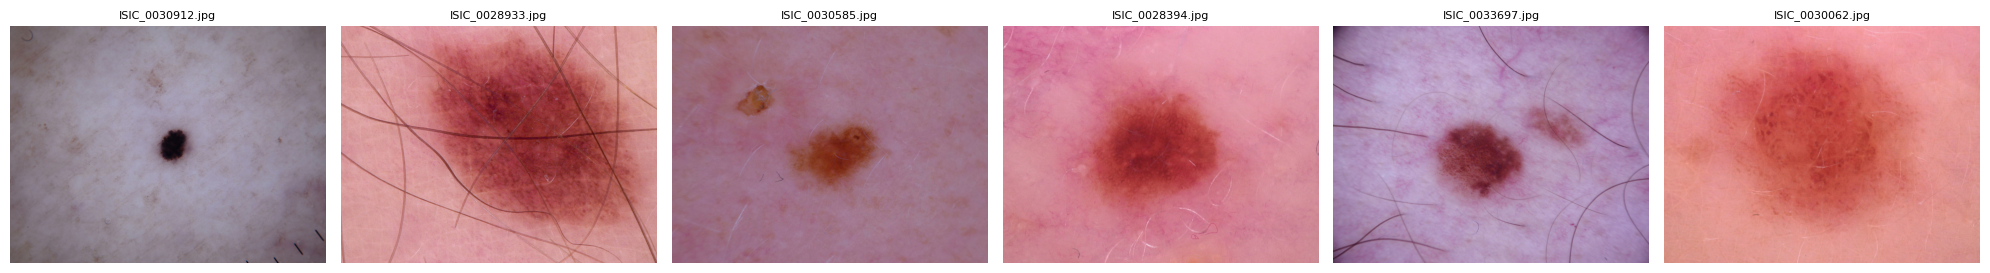

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Define the root directory containing the images
image_root_dir = os.path.join(path, 'images')

print(f"Checking for images in: {image_root_dir}")
if not os.path.exists(image_root_dir):
    print(f"Error: Directory '{image_root_dir}' not found.")
else:
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    # Scan through the images folder directly
    for root, dirs, files in os.walk(image_root_dir):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if all_image_paths:
        print(f"\nFound {len(all_image_paths)} image files in total. Displaying samples:")

        # Select up to 6 samples to display
        num_samples = min(len(all_image_paths), 6)
        samples_to_display = all_image_paths[:num_samples]

        fig, axes = plt.subplots(1, num_samples, figsize=(20, 5))
        if num_samples == 1:
            axes = [axes]

        for i, img_path in enumerate(samples_to_display):
            try:
                img = Image.open(img_path)
                axes[i].imshow(img)
                # Show the filename
                axes[i].set_title(os.path.basename(img_path), fontsize=8)
                axes[i].axis('off')
            except Exception as e:
                print(f"Error loading {img_path}: {e}")

        plt.tight_layout()
        plt.show()
    else:
        print("\nNo images found in the 'images' folder.")

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd
import os

# Path to the metadata file containing labels
metadata_path = os.path.join(path, 'GroundTruth.csv')

if os.path.exists(metadata_path):
    # Read data from CSV file
    df = pd.read_csv(metadata_path)

    # Split dataset into train (80%) and test (20%)
    # random_state=42 ensures reproducibility
    train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

    print(f"Total samples: {len(df)}")
    print(f"Training set size: {len(train_df)} (80%)")
    print(f"Testing set size: {len(test_df)} (20%)")

    # Display first few rows of the training set
    display(train_df.head())
else:
    # If no metadata file exists, split based on image paths
    train_paths, test_paths = train_test_split(all_image_paths, test_size=0.2, random_state=42)
    print(f"GroundTruth.csv not found. Splitting directly from image file list:")
    print(f"Training image count: {len(train_paths)}")
    print(f"Testing image count: {len(test_paths)}")

Total samples: 10015
Training set size: 8012 (80%)
Testing set size: 2003 (20%)


,image,MEL,NV,BCC,AKIEC,BKL,DF,VASC
6582,ISIC_0030888,0.0,1.0,0.0,0.0,0.0,0.0,0.0
7194,ISIC_0031500,0.0,1.0,0.0,0.0,0.0,0.0,0.0
9446,ISIC_0033752,1.0,0.0,0.0,0.0,0.0,0.0,0.0
533,ISIC_0024839,0.0,0.0,0.0,0.0,1.0,0.0,0.0
132,ISIC_0024438,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import numpy as np

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(torch.cuda.get_device_name(0))

Using device: cuda
Tesla T4


In [ ]:
class SkinLesionDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.df = dataframe
        self.image_dir = image_dir
        self.transform = transform
        # Labels are column indices 1 to 7 in GroundTruth.csv
        self.labels = self.df.iloc[:, 1:].values.argmax(axis=1)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx, 0] + '.jpg'
        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

# Transformations
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Datasets & Loaders
train_dataset = SkinLesionDataset(train_df, image_root_dir, transform=data_transforms['train'])
test_dataset = SkinLesionDataset(test_df, image_root_dir, transform=data_transforms['test'])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 7)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(num_epochs):
    # Training Phase
    model.train()
    running_loss = 0.0
    running_corrects = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        _, preds = torch.max(outputs, 1)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = running_corrects.double() / len(train_loader.dataset)

    # Validation Phase
    model.eval()
    val_running_loss = 0.0
    val_running_corrects = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)

            val_running_loss += loss.item() * images.size(0)
            val_running_corrects += torch.sum(preds == labels.data)

    val_loss = val_running_loss / len(test_loader.dataset)
    val_acc = val_running_corrects.double() / len(test_loader.dataset)

    history['train_loss'].append(epoch_loss)
    history['train_acc'].append(epoch_acc.item())
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc.item())

    print(f'Epoch {epoch+1}/{num_epochs}')
    print(f'Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
    print(f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')
    print('-' * 10)

Epoch 1/10
Train Loss: 0.8082 Acc: 0.7071
Val Loss: 0.7750 Acc: 0.7244
----------
Epoch 2/10
Train Loss: 0.6825 Acc: 0.7511
Val Loss: 1.1122 Acc: 0.6350
----------
Epoch 3/10
Train Loss: 0.6449 Acc: 0.7625
Val Loss: 0.8534 Acc: 0.7209
----------
Epoch 4/10
Train Loss: 0.5977 Acc: 0.7836
Val Loss: 0.6812 Acc: 0.7544
----------
Epoch 5/10
Train Loss: 0.5635 Acc: 0.7919
Val Loss: 0.7192 Acc: 0.7544
----------
Epoch 6/10
Train Loss: 0.5348 Acc: 0.8005
Val Loss: 0.6785 Acc: 0.7509
----------
Epoch 7/10
Train Loss: 0.4907 Acc: 0.8195
Val Loss: 0.6063 Acc: 0.7768
----------
Epoch 8/10
Train Loss: 0.4441 Acc: 0.8374
Val Loss: 0.6148 Acc: 0.7808
----------
Epoch 9/10
Train Loss: 0.4210 Acc: 0.8420
Val Loss: 0.6958 Acc: 0.7659
----------
Epoch 10/10
Train Loss: 0.3713 Acc: 0.8603
Val Loss: 0.5806 Acc: 0.8038
----------


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("--- Classification Report ---")
target_names = df.columns[1:].tolist()
print(classification_report(all_labels, all_preds, target_names=target_names))

--- Classification Report ---
              precision    recall  f1-score   support

         MEL       0.53      0.69      0.60       239
          NV       0.90      0.90      0.90      1338
         BCC       0.68      0.74      0.71       106
       AKIEC       0.75      0.24      0.37        62
         BKL       0.66      0.55      0.60       206
          DF       0.67      0.36      0.47        22
        VASC       0.96      0.83      0.89        30

    accuracy                           0.80      2003
   macro avg       0.73      0.62      0.65      2003
weighted avg       0.81      0.80      0.80      2003



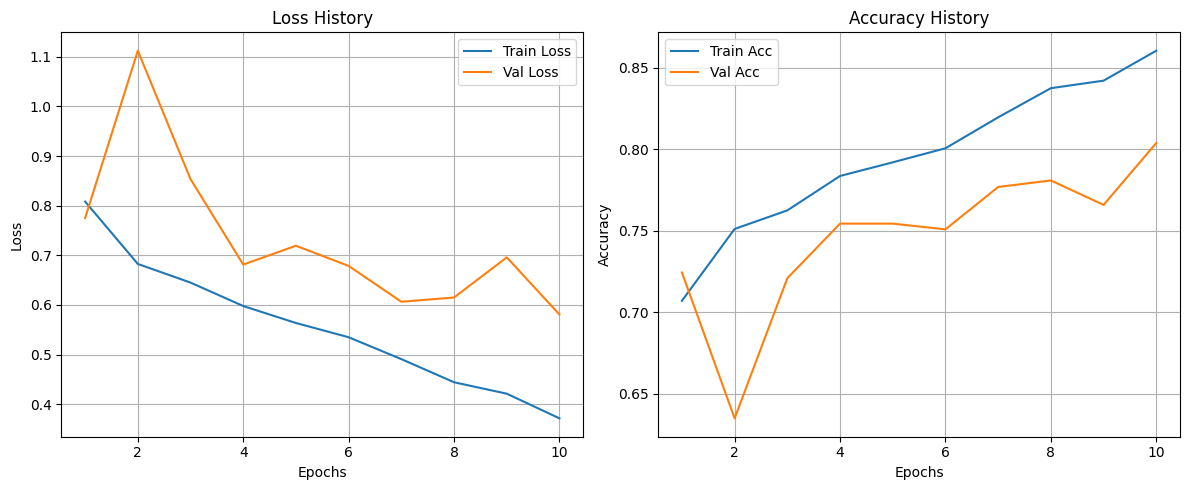

In [ ]:
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), history['train_loss'], label='Train Loss')
plt.plot(range(1, num_epochs+1), history['val_loss'], label='Val Loss')
plt.title('Loss History')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), history['train_acc'], label='Train Acc')
plt.plot(range(1, num_epochs+1), history['val_acc'], label='Val Acc')
plt.title('Accuracy History')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()